# Distribution Sanity Checks — v4

Refactor of v3 with four focused changes:

1. **Fix → rule distribution evaluation (revised).** Replaces v3's
   bar-chart violation-count comparison with pre/post histograms plus
   distribution-shift diagnostics (Δ at p25/p50/p75, Cohen's d effect
   size). Tier change is no longer mixed into the fix narrative.

2. **Rule set updated.** `billex_too_few_rows` removed (redundant with
   `billex_low_retention`, which catches the same dicts plus avoids
   13 false positives). `billex_low_retention` is now the only billex
   row-related rule.

3. **Per-rule flag analysis (new).** Counts how many dicts each rule
   flags, plus pairwise overlap (count, Jaccard, conditional
   probability). Identifies redundant rule pairs and independent
   rule pairs.

4. **Per-resource tier presentation simplified.** Headline view shows
   post-fix tier counts only. Pre/post transition matrices kept as
   secondary detail (so you can still defend "fixes did something")
   but no longer presented as standalone pre-fix counts.

## Outputs (in `../csvAnalysis/sanity_v4/`)

- `_per_dict_metrics.csv` — wide format with per-resource and overall tiers
- `_quality_tiers.csv` — per-dict tier summary
- `_per_resource_transitions.csv` — tier transition counts per resource
- `_fix_distribution_shifts.csv` — per-rule shift diagnostics (NEW)
- `_per_rule_flags.csv` — flag count and rate per rule (NEW)
- `_rule_overlap_long.csv` — long-format pairwise overlap stats (NEW)
- `_rule_overlap_matrix.csv` — wide-format overlap count matrix (NEW)
- `_catastrophic_failures.csv` — extraction-stage failures
- `_aggregate_stats.csv` — single-row corpus summary

Plots:
- `_postfix_distributions.png` — pre/post histograms for targeted rules (NEW)
- `_postfix_tier_breakdown.png` — overall + per-resource post-fix counts
- `_tier_transitions.png` — 3-panel transition heatmaps
- `_rule_overlap_matrix.png` — overlap heatmap (NEW)

v3 outputs in `../csvAnalysis/sanity_v3/` left intact for comparison.

## 1. Imports & paths

In [1]:
import re
import ast
from pathlib import Path
from typing import Optional
from itertools import combinations

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from _common import parse_dict_id, load_direction_lookup, direction_for

DIRS = {
    "prep":         Path("../Ekstraksi/6. Pemecahan Definisi Lema"),
    "billex":       Path("../Ekstraksi/9. Bilingual Lexicon"),
    "morph":        Path("../Ekstraksi/10. Morphology"),
    "parcor":       Path("../Ekstraksi/11. Parallel Corpus"),
    "billex_fixed": Path("../Ekstraksi/9. Bilingual Lexicon - Fixed"),
    "morph_fixed":  Path("../Ekstraksi/10. Morphology - Fixed"),
    "parcor_fixed": Path("../Ekstraksi/11. Parallel Corpus - Fixed"),
}

CALIBRATION = Path("../csvAnalysis/distribution_exploration/_strict_thresholds.csv")
DST_DIR = Path("../csvAnalysis/sanity_v4")
DST_DIR.mkdir(parents=True, exist_ok=True)

# v3 design parameter (unchanged)
BROKEN_PROPORTION_THRESHOLD = 0.60

# Retention computation guard
RETENTION_MIN_PREP_ROWS = 100

for name, d in DIRS.items():
    print(f"  {name:<14}  exists={d.exists()}  {d}")
print(f"\n  calibration    exists={CALIBRATION.exists()}  {CALIBRATION}")
print(f"\nWriting to: {DST_DIR.resolve()}")

assert CALIBRATION.exists(), (
    f"Run Threshold Calibration.ipynb first to produce {CALIBRATION}"
)

  prep            exists=True  ..\Ekstraksi\6. Pemecahan Definisi Lema
  billex          exists=True  ..\Ekstraksi\9. Bilingual Lexicon
  morph           exists=True  ..\Ekstraksi\10. Morphology
  parcor          exists=True  ..\Ekstraksi\11. Parallel Corpus
  billex_fixed    exists=True  ..\Ekstraksi\9. Bilingual Lexicon - Fixed
  morph_fixed     exists=True  ..\Ekstraksi\10. Morphology - Fixed
  parcor_fixed    exists=True  ..\Ekstraksi\11. Parallel Corpus - Fixed

  calibration    exists=True  ..\csvAnalysis\distribution_exploration\_strict_thresholds.csv

Writing to: C:\Users\Legion\OneDrive\Documents\UNI\TA\tugas-akhir-data-mining\TAEkstraksiKamus\csvAnalysis\sanity_v4


## 2. Load calibrated thresholds

Same as v3 except:
- `billex_too_few_rows` is excluded (redundant with `billex_low_retention`)
- `billex_low_retention` is included as a billex rule

This is the same calibration file as v3; we just filter the rule set after loading.

In [2]:
thresholds_df = pd.read_csv(CALIBRATION)
print(f"Loaded {len(thresholds_df)} calibrated thresholds")

# Rules excluded in v4
EXCLUDED_RULES = {"billex_too_few_rows"}
thresholds_df = thresholds_df[~thresholds_df["rule_name"].isin(EXCLUDED_RULES)].reset_index(drop=True)

RESOURCE_RULES = {
    "billex": [],
    "morph":  [],
    "parcor": [],
}
for _, row in thresholds_df.iterrows():
    rule = row["rule_name"]
    for resource in RESOURCE_RULES:
        if rule.startswith(resource + "_"):
            RESOURCE_RULES[resource].append({
                "rule": rule,
                "metric": row["metric_column"],
                "threshold": row["chosen_threshold"],
                "direction": row["direction"],
            })
            break

for r, rules in RESOURCE_RULES.items():
    n = len(rules)
    threshold_pct = int(BROKEN_PROPORTION_THRESHOLD * 100)
    min_for_broken = int(np.ceil(n * BROKEN_PROPORTION_THRESHOLD))
    print(f"  {r}: {n} rules → broken if ≥{min_for_broken}/{n} violated (≥{threshold_pct}%)")
    for rule_info in rules:
        print(f"    - {rule_info['rule']}")

print(f"\nExcluded rules: {EXCLUDED_RULES}")

Loaded 9 calibrated thresholds
  billex: 3 rules → broken if ≥2/3 violated (≥60%)
    - billex_high_multiword_ind
    - billex_high_null_rate
    - billex_low_retention
  morph: 2 rules → broken if ≥2/2 violated (≥60%)
    - morph_low_tag_coverage
    - morph_too_few_rows
  parcor: 4 rules → broken if ≥3/4 violated (≥60%)
    - parcor_high_placeholders
    - parcor_too_few_rows
    - parcor_high_null_rate
    - parcor_high_short_rows

Excluded rules: {'billex_too_few_rows'}


## 3. Fix-to-rule mapping

Used by §8 (fix evaluation) only. No longer feeds into tier classification.

In [3]:
FIX_TO_RULES = {
    "fix_billex_headword_batch":    ["billex_high_multiword_ind"],
    "fix_morphology_split_batch":   ["morph_low_tag_coverage"],
    "fix_parcor_batch":             ["parcor_high_placeholders"],
}
RULE_TO_FIX = {rule: fix for fix, rules in FIX_TO_RULES.items() for rule in rules}

# For each targeted rule, the metric column to use for distribution comparison
RULE_METRIC_COLUMNS = {
    "billex_high_multiword_ind": ("billex_multiword_ind_rate", "billex_fixed_multiword_ind_rate"),
    "morph_low_tag_coverage":    ("morph_tag_coverage",         "morph_fixed_tag_coverage"),
    "parcor_high_placeholders":  ("parcor_placeholder_rate",    "parcor_fixed_placeholder_rate"),
}

## 4. Source feature detection (Parcor only — same as v3)

In [4]:
PARCOR_SOURCE_THRESHOLD = 0.10


def detect_parcor_source(dict_id: str) -> dict:
    prep_files = list(DIRS["prep"].glob(f"{dict_id}_*.csv")) if DIRS["prep"].exists() else []
    if not prep_files:
        return {"has_examples": True, "example_rate": float("nan"), "prep_rows": 0}
    try:
        prep = pd.read_csv(prep_files[0])
    except Exception:
        return {"has_examples": True, "example_rate": float("nan"), "prep_rows": 0}
    if "contoh_kalimat" not in prep.columns or len(prep) == 0:
        return {"has_examples": True, "example_rate": float("nan"), "prep_rows": len(prep)}

    has_content = prep["contoh_kalimat"].notna() & (
        prep["contoh_kalimat"].astype(str).str.strip() != ""
    )
    rate = has_content.mean()
    return {
        "has_examples": bool(rate >= PARCOR_SOURCE_THRESHOLD),
        "example_rate": round(float(rate), 4),
        "prep_rows": len(prep),
    }

## 5. Per-resource metric collectors (same as v3, plus retention)

In [5]:
def parse_list_cell(s):
    if isinstance(s, list): return s
    try:
        v = ast.literal_eval(s) if isinstance(s, str) else []
        return v if isinstance(v, list) else []
    except Exception:
        return []


def collect_billex_metrics(path: Path, direction: Optional[int]) -> dict:
    df = pd.read_csv(path)
    n = len(df)
    if n == 0 or "kata_asal" not in df.columns or "kata_tujuan" not in df.columns:
        return {"billex_rows": n}

    if direction == 1:
        ind_col, reg_col = "kata_asal", "kata_tujuan"
    else:
        ind_col, reg_col = "kata_tujuan", "kata_asal"

    def first_of(v):
        if not isinstance(v, str): return ""
        lst = parse_list_cell(v)
        if lst:
            first = lst[0]
            return str(first).strip() if first is not None else ""
        return v.strip()

    if direction == 1:
        ind_series = df[ind_col].fillna("").astype(str).str.strip()
    else:
        ind_series = df[ind_col].apply(first_of)

    null_rate = df[[ind_col, reg_col]].isna().any(axis=1).mean()
    multiword_ind_rate = ind_series.str.contains(r"\s", na=False, regex=True).mean()

    return {
        "billex_rows": n,
        "billex_null_rate": round(float(null_rate), 4),
        "billex_multiword_ind_rate": round(float(multiword_ind_rate), 4),
    }


def collect_morph_metrics(path: Path) -> dict:
    df = pd.read_csv(path)
    n = len(df)
    if n == 0:
        return {"morph_rows": 0}
    if "tag" in df.columns:
        tag_col = df["tag"].fillna("").astype(str).str.strip()
        rate = ((tag_col != "") & (tag_col.str.lower() != "nan")).mean()
    else:
        rate = 0.0
    return {"morph_rows": n, "morph_tag_coverage": round(float(rate), 4)}


def collect_parcor_metrics(path: Path) -> dict:
    df = pd.read_csv(path)
    n = len(df)
    if n == 0:
        return {"parcor_rows": 0}
    if "kalimat_asal" not in df.columns or "kalimat_tujuan" not in df.columns:
        return {"parcor_rows": n, "parcor_null_rate": 1.0}

    asal = df["kalimat_asal"].fillna("").astype(str)
    tujuan = df["kalimat_tujuan"].fillna("").astype(str)
    null_rate = df[["kalimat_asal", "kalimat_tujuan"]].isna().any(axis=1).mean()
    placeholder_re = re.compile(r"(?:^|\s)(--|-)(?=\s|$|[.,;:!?])")
    ph_rate = asal.str.contains(placeholder_re, na=False, regex=True).mean()
    len_asal = asal.apply(lambda s: len(s.split()) if isinstance(s, str) else 0)
    len_tujuan = tujuan.apply(lambda s: len(s.split()) if isinstance(s, str) else 0)
    short_rate = ((len_asal <= 2) | (len_tujuan <= 2)).mean()

    return {
        "parcor_rows": n,
        "parcor_null_rate": round(float(null_rate), 4),
        "parcor_placeholder_rate": round(float(ph_rate), 4),
        "parcor_short_rate": round(float(short_rate), 4),
    }

## 6. Tier assignment with proportional rule (unchanged from v3)

- good: 0 violations
- needs_attention: ≥1 violation, proportion < 60%
- broken: proportion of applicable rules violated ≥ 60%

In [6]:
def check_violations_for_resource(metrics: dict, resource: str) -> list:
    violated = []
    for rule_info in RESOURCE_RULES[resource]:
        metric_val = metrics.get(rule_info["metric"])
        if metric_val is None or (isinstance(metric_val, float) and np.isnan(metric_val)):
            continue
        if rule_info["direction"] == "high" and metric_val > rule_info["threshold"]:
            violated.append(rule_info["rule"])
        elif rule_info["direction"] == "low" and metric_val < rule_info["threshold"]:
            violated.append(rule_info["rule"])
    return violated


def assign_tier(n_violations: int, n_applicable_rules: int,
                threshold: float = BROKEN_PROPORTION_THRESHOLD) -> str:
    if n_applicable_rules == 0:
        return "not_applicable"
    if n_violations == 0:
        return "good"
    proportion = n_violations / n_applicable_rules
    if proportion >= threshold:
        return "broken"
    return "needs_attention"

print("Tier cutoff summary:")
for resource, rules in RESOURCE_RULES.items():
    n = len(rules)
    needed_for_broken = int(np.ceil(n * BROKEN_PROPORTION_THRESHOLD))
    print(f"  {resource}: 0 → good, 1..{needed_for_broken-1} → needs_attention, {needed_for_broken}..{n} → broken")

Tier cutoff summary:
  billex: 0 → good, 1..1 → needs_attention, 2..3 → broken
  morph: 0 → good, 1..1 → needs_attention, 2..2 → broken
  parcor: 0 → good, 1..2 → needs_attention, 3..4 → broken


## 7. Process every dictionary

In [7]:
direction_lookup = load_direction_lookup()

billex_files = sorted(DIRS["billex"].glob("*_Billex.csv")) if DIRS["billex"].exists() else []
dict_ids = sorted({parse_dict_id(p.name) for p in billex_files} - {None}, key=lambda s: int(s))
print(f"Found {len(dict_ids)} dictionaries\n")


def find_csv(dir_: Path, dict_id: str, suffix: str) -> Optional[Path]:
    if not dir_.exists(): return None
    matches = list(dir_.glob(f"{dict_id}_{suffix}.csv"))
    return matches[0] if matches else None


all_metrics = []
for dict_id in dict_ids:
    m = {
        "dict_id": dict_id,
        "direction": direction_for(dict_id, direction_lookup),
    }

    src = detect_parcor_source(dict_id)
    m["parcor_has_examples_in_source"] = src["has_examples"]
    m["parcor_source_example_rate"]    = src["example_rate"]
    m["prep_rows"]                     = src["prep_rows"]

    # Original metrics
    for resource, suffix, collector in [
        ("billex", "Billex", lambda p: collect_billex_metrics(p, m["direction"] or 1)),
        ("morph",  "Morphology", collect_morph_metrics),
        ("parcor", "Parcor", collect_parcor_metrics),
    ]:
        p = find_csv(DIRS[resource], dict_id, suffix)
        if p:
            m.update(collector(p))

    # Compute billex retention (only billex has a retention rule in v4)
    if m.get("prep_rows", 0) >= RETENTION_MIN_PREP_ROWS and "billex_rows" in m:
        m["billex_retention"] = round(m["billex_rows"] / m["prep_rows"], 4)
    else:
        m["billex_retention"] = np.nan

    # Fixed metrics
    for resource, suffix, collector in [
        ("billex_fixed", "Billex", lambda p: collect_billex_metrics(p, m["direction"] or 1)),
        ("morph_fixed",  "Morphology", collect_morph_metrics),
        ("parcor_fixed", "Parcor", collect_parcor_metrics),
    ]:
        p = find_csv(DIRS[resource], dict_id, suffix)
        if p:
            fixed_metrics = collector(p)
            for k, v in fixed_metrics.items():
                new_key = k.replace(
                    resource.split("_")[0] + "_",
                    resource.split("_")[0] + "_fixed_",
                    1,
                )
                m[new_key] = v

    # Recompute fixed billex retention
    if m.get("prep_rows", 0) >= RETENTION_MIN_PREP_ROWS and "billex_fixed_rows" in m:
        m["billex_fixed_retention"] = round(m["billex_fixed_rows"] / m["prep_rows"], 4)
    else:
        m["billex_fixed_retention"] = np.nan

    # Per-resource tier — pre-fix
    for resource in ["billex", "morph", "parcor"]:
        violations = check_violations_for_resource(m, resource)
        n_rules = len(RESOURCE_RULES[resource])
        m[f"{resource}_violations_prefix"] = ";".join(violations)
        m[f"{resource}_violation_count_prefix"] = len(violations)
        m[f"{resource}_tier_prefix"] = assign_tier(len(violations), n_rules)

    if not m.get("parcor_has_examples_in_source", True):
        m["parcor_tier_prefix"] = "not_applicable"
        m["parcor_violations_prefix"] = ""
        m["parcor_violation_count_prefix"] = 0

    # Per-resource tier — post-fix (substitute fixed values in)
    m_post = dict(m)
    for key in list(m):
        for resource in ["billex", "morph", "parcor"]:
            prefix = f"{resource}_"
            fixed_prefix = f"{resource}_fixed_"
            if key.startswith(prefix) and not key.startswith(fixed_prefix):
                fixed_key = key.replace(prefix, fixed_prefix, 1)
                if fixed_key in m:
                    m_post[key] = m[fixed_key]

    for resource in ["billex", "morph", "parcor"]:
        violations = check_violations_for_resource(m_post, resource)
        n_rules = len(RESOURCE_RULES[resource])
        m[f"{resource}_violations_postfix"] = ";".join(violations)
        m[f"{resource}_violation_count_postfix"] = len(violations)
        m[f"{resource}_tier_postfix"] = assign_tier(len(violations), n_rules)

    if not m.get("parcor_has_examples_in_source", True):
        m["parcor_tier_postfix"] = "not_applicable"
        m["parcor_violations_postfix"] = ""
        m["parcor_violation_count_postfix"] = 0

    all_metrics.append(m)

metrics_df = pd.DataFrame(all_metrics).sort_values(
    "dict_id", key=lambda s: s.astype(int)
).reset_index(drop=True)
metrics_df.to_csv(DST_DIR / "_per_dict_metrics.csv", index=False)
print(f"Wrote metrics: {len(metrics_df)} dicts × {len(metrics_df.columns)} columns")

Found 68 dictionaries



C:\Users\Legion\AppData\Local\Temp\ipykernel_14552\3709671438.py:69: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ph_rate = asal.str.contains(placeholder_re, na=False, regex=True).mean()
C:\Users\Legion\AppData\Local\Temp\ipykernel_14552\3709671438.py:69: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ph_rate = asal.str.contains(placeholder_re, na=False, regex=True).mean()
C:\Users\Legion\AppData\Local\Temp\ipykernel_14552\3709671438.py:69: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ph_rate = asal.str.contains(placeholder_re, na=False, regex=True).mean()
C:\Users\Legion\AppData\Local\Temp\ipykernel_14552\3709671438.py:69: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually 

Wrote metrics: 68 dicts × 43 columns


C:\Users\Legion\AppData\Local\Temp\ipykernel_14552\3709671438.py:69: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ph_rate = asal.str.contains(placeholder_re, na=False, regex=True).mean()
C:\Users\Legion\AppData\Local\Temp\ipykernel_14552\3709671438.py:69: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ph_rate = asal.str.contains(placeholder_re, na=False, regex=True).mean()
C:\Users\Legion\AppData\Local\Temp\ipykernel_14552\3709671438.py:69: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ph_rate = asal.str.contains(placeholder_re, na=False, regex=True).mean()
C:\Users\Legion\AppData\Local\Temp\ipykernel_14552\3709671438.py:69: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually 

## 8. Fix → Rule Distribution Evaluation

Standalone narrative. For each fix script, look at the distribution of its
targeted metric pre- and post-fix, and report shift diagnostics.

This replaces v3's bar chart of pre/post violation counts. The histogram
view shows *how* the distribution changed (shape shift, median move,
spread change), not just whether it crossed a threshold.

### 8.1 Pre/post histograms with median lines

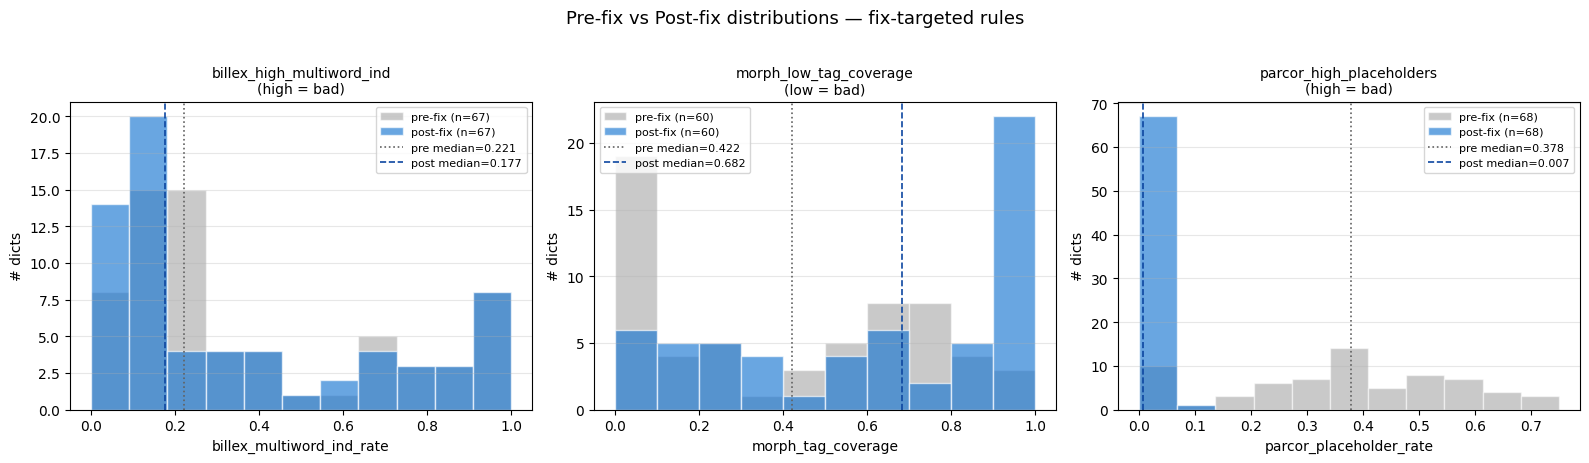

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, (rule, (pre_col, post_col)) in zip(axes, RULE_METRIC_COLUMNS.items()):
    if pre_col not in metrics_df.columns or post_col not in metrics_df.columns:
        ax.text(0.5, 0.5, f"(missing column for {rule})",
                ha="center", va="center", transform=ax.transAxes)
        ax.set_title(rule, fontsize=10)
        continue

    pre_vals  = metrics_df[pre_col].dropna().values
    post_vals = metrics_df[post_col].dropna().values

    if len(pre_vals) == 0 or len(post_vals) == 0:
        ax.text(0.5, 0.5, f"(insufficient data)", ha="center", va="center", transform=ax.transAxes)
        continue

    # Use 20 bins on the PRE-fix data range, matching the diagnostics convention.
    # Apply same bins to post-fix so direct comparison is possible.
    all_vals = np.concatenate([pre_vals, post_vals])
    n_bins = min(25, max(10, int(np.sqrt(len(all_vals)))))
    bin_edges = np.linspace(all_vals.min(), all_vals.max(), n_bins + 1)

    ax.hist(pre_vals,  bins=bin_edges, alpha=0.55, color="#9e9e9e",
            edgecolor="white", label=f"pre-fix (n={len(pre_vals)})")
    ax.hist(post_vals, bins=bin_edges, alpha=0.65, color="#1976d2",
            edgecolor="white", label=f"post-fix (n={len(post_vals)})")

    ax.axvline(np.median(pre_vals), color="#616161", linestyle=":", linewidth=1.2,
               label=f"pre median={np.median(pre_vals):.3f}")
    ax.axvline(np.median(post_vals), color="#0d47a1", linestyle="--", linewidth=1.2,
               label=f"post median={np.median(post_vals):.3f}")

    direction = next(r["direction"] for rules in RESOURCE_RULES.values() for r in rules
                     if r["rule"] == rule)
    direction_phrase = "low = bad" if direction == "low" else "high = bad"
    ax.set_title(f"{rule}\n({direction_phrase})", fontsize=10)
    ax.set_xlabel(pre_col)
    ax.set_ylabel("# dicts")
    ax.legend(fontsize=8, loc="best")
    ax.grid(alpha=0.3, axis="y")

plt.suptitle("Pre-fix vs Post-fix distributions — fix-targeted rules",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(DST_DIR / "_postfix_distributions.png", dpi=120, bbox_inches="tight")
plt.show()

### 8.2 Distribution shift diagnostics

For each targeted rule, compute:
- **Δp25, Δp50, Δp75**: change at each quartile (post − pre)
- **Cohen's d effect size**: `(mean_post − mean_pre) / pooled_std`
  - |d| < 0.2: negligible
  - 0.2 ≤ |d| < 0.5: small
  - 0.5 ≤ |d| < 0.8: medium
  - |d| ≥ 0.8: large
- **Direction-aware verdict**: did the shift improve quality (lower if direction=high, higher if direction=low)?

In [9]:
def cohens_d(pre, post):
    """Cohen's d effect size for two independent samples."""
    pre, post = np.asarray(pre), np.asarray(post)
    n_pre, n_post = len(pre), len(post)
    if n_pre < 2 or n_post < 2:
        return float("nan")
    var_pre  = np.var(pre,  ddof=1)
    var_post = np.var(post, ddof=1)
    pooled = np.sqrt(((n_pre - 1) * var_pre + (n_post - 1) * var_post) /
                     (n_pre + n_post - 2))
    if pooled < 1e-9:
        return 0.0
    return float((np.mean(post) - np.mean(pre)) / pooled)


def interpret_d(d):
    if np.isnan(d): return "n/a"
    return "small" if abs(d) < 0.5 else "large"


shift_rows = []
for rule, (pre_col, post_col) in RULE_METRIC_COLUMNS.items():
    if pre_col not in metrics_df.columns or post_col not in metrics_df.columns:
        continue
    pre  = metrics_df[pre_col].dropna().values
    post = metrics_df[post_col].dropna().values
    if len(pre) == 0 or len(post) == 0:
        continue

    pre_p25, pre_p50, pre_p75    = np.percentile(pre,  [25, 50, 75])
    post_p25, post_p50, post_p75 = np.percentile(post, [25, 50, 75])
    d = cohens_d(pre, post)

    direction = next(r["direction"] for rules in RESOURCE_RULES.values() for r in rules
                     if r["rule"] == rule)
    delta_median = post_p50 - pre_p50
    if direction == "low":  # higher metric value is better
        improved = delta_median > 0
    else:  # lower metric value is better
        improved = delta_median < 0

    if abs(delta_median) < 1e-9:
        verdict = "no_change"
    elif improved:
        verdict = "improved"
    else:
        verdict = "regressed"

    shift_rows.append({
        "rule":          rule,
        "fix_script":    RULE_TO_FIX.get(rule, "(none)"),
        "direction":     direction,
        "n":             len(pre),
        "pre_median":    round(float(pre_p50),  4),
        "post_median":   round(float(post_p50), 4),
        "delta_p25":     round(float(post_p25 - pre_p25), 4),
        "delta_p50":     round(float(post_p50 - pre_p50), 4),
        "delta_p75":     round(float(post_p75 - pre_p75), 4),
        "cohens_d":      round(d, 3) if not np.isnan(d) else None,
        "effect_size":   interpret_d(d),
        "verdict":       verdict,
    })

shift_df = pd.DataFrame(shift_rows)
shift_df.to_csv(DST_DIR / "_fix_distribution_shifts.csv", index=False)

print("=== Distribution Shift Diagnostics ===\n")
print(shift_df.to_string(index=False))

=== Distribution Shift Diagnostics ===

                     rule                 fix_script direction  n  pre_median  post_median  delta_p25  delta_p50  delta_p75  cohens_d effect_size  verdict
billex_high_multiword_ind  fix_billex_headword_batch      high 67      0.2211       0.1770    -0.0423    -0.0441     0.0000    -0.077       small improved
   morph_low_tag_coverage fix_morphology_split_batch       low 60      0.4222       0.6824     0.2738     0.2602     0.2473     0.618       large improved
 parcor_high_placeholders           fix_parcor_batch      high 68      0.3778       0.0070    -0.2294    -0.3708    -0.5032    -2.430       large improved


## 9. Per-Resource Quality Tiers

§9.1 leads with **post-fix counts** as the headline view.

§9.2 keeps **transition matrices** so the pre→post movement is still
visible — but pre-fix tier counts no longer get a standalone section.

§9.3 reports the broken-on-N-resources breakdown (post-fix only).

### 9.1 Post-fix per-resource tier counts (headline)

In [10]:
tier_order = ["good", "needs_attention", "broken", "not_applicable"]

per_resource_postfix = pd.DataFrame({
    r: metrics_df[f"{r}_tier_postfix"].value_counts().reindex(tier_order, fill_value=0)
    for r in ["billex", "morph", "parcor"]
}).T

print("=== Per-resource tier counts (post-fix) ===\n")
print(per_resource_postfix)

=== Per-resource tier counts (post-fix) ===

        good  needs_attention  broken  not_applicable
billex    23               14      31               0
morph     21               19      28               0
parcor    14               43      11               0


### 9.2 Per-resource transitions (pre → post)

In [11]:
transitions_data = {}
for resource in ["billex", "morph", "parcor"]:
    pre_col  = f"{resource}_tier_prefix"
    post_col = f"{resource}_tier_postfix"
    transitions = pd.crosstab(
        metrics_df[pre_col], metrics_df[post_col], margins=True
    ).reindex(
        index=tier_order + ["All"], columns=tier_order + ["All"], fill_value=0
    )
    transitions_data[resource] = transitions
    print(f"\n=== {resource.upper()} tier transitions (rows=pre, cols=post) ===")
    print(transitions)

# Long-format export
trans_long = []
for resource, trans in transitions_data.items():
    for pre_tier in tier_order:
        for post_tier in tier_order:
            trans_long.append({
                "resource":  resource,
                "pre_tier":  pre_tier,
                "post_tier": post_tier,
                "count":     int(trans.loc[pre_tier, post_tier]),
            })
trans_long_df = pd.DataFrame(trans_long)
trans_long_df.to_csv(DST_DIR / "_per_resource_transitions.csv", index=False)


=== BILLEX tier transitions (rows=pre, cols=post) ===
billex_tier_postfix  good  needs_attention  broken  not_applicable  All
billex_tier_prefix                                                     
good                   23                0       0               0   23
needs_attention         0               14       0               0   14
broken                  0                0      31               0   31
not_applicable          0                0       0               0    0
All                    23               14      31               0   68

=== MORPH tier transitions (rows=pre, cols=post) ===
morph_tier_postfix  good  needs_attention  broken  not_applicable  All
morph_tier_prefix                                                     
good                   8                0       0               0    8
needs_attention       13               14       0               0   27
broken                 0                5      28               0   33
not_applicable         0        

### 9.3 Broken-on-N-resources breakdown (post-fix)

In [12]:
n_broken = (
    (metrics_df["billex_tier_postfix"] == "broken").astype(int)
    + (metrics_df["morph_tier_postfix"] == "broken").astype(int)
    + (metrics_df["parcor_tier_postfix"] == "broken").astype(int)
)
metrics_df["n_resources_broken_postfix"] = n_broken

breakdown = pd.DataFrame({
    "n_resources_broken": [0, 1, 2, 3],
    "count": [int((n_broken == k).sum()) for k in [0, 1, 2, 3]],
    "interpretation": [
        "no resources broken (good or needs_attention only)",
        "exactly 1 resource broken",
        "2 of 3 resources broken",
        "all 3 resources broken (catastrophically broken)",
    ],
})
print("=== Dicts broken on N resources (post-fix) ===\n")
print(breakdown.to_string(index=False))

all_three = metrics_df[n_broken == 3]
if len(all_three) > 0:
    print(f"\nDicts broken on all 3 resources: "
          f"{', '.join(all_three['dict_id'].astype(str).tolist())}")

=== Dicts broken on N resources (post-fix) ===

 n_resources_broken  count                                     interpretation
                  0     27 no resources broken (good or needs_attention only)
                  1     17                          exactly 1 resource broken
                  2     19                            2 of 3 resources broken
                  3      5   all 3 resources broken (catastrophically broken)

Dicts broken on all 3 resources: 11, 50, 51, 67, 84


### 9.4 Per-dict tier export

In [13]:
tier_cols = [
    "dict_id",
    "billex_tier_prefix", "morph_tier_prefix", "parcor_tier_prefix",
    "billex_tier_postfix", "morph_tier_postfix", "parcor_tier_postfix",
    "billex_violations_prefix", "morph_violations_prefix", "parcor_violations_prefix",
    "billex_violations_postfix", "morph_violations_postfix", "parcor_violations_postfix",
    "n_resources_broken_postfix",
    "parcor_has_examples_in_source",
]
available = [c for c in tier_cols if c in metrics_df.columns]
metrics_df[available].to_csv(DST_DIR / "_quality_tiers.csv", index=False)
print(f"Wrote tier table: {DST_DIR / '_quality_tiers.csv'}")

Wrote tier table: ..\csvAnalysis\sanity_v4\_quality_tiers.csv


## 10. Per-Rule Flag Analysis

For each rule, compute:
- How many dicts it flags (post-fix)
- Pairwise overlap with every other rule, with three measures:
  - **Count**: number of dicts both rules flag
  - **Jaccard**: |A ∩ B| / |A ∪ B| (symmetric, 0–1, higher = more overlap)
  - **Conditional probability**: P(B | A) = |A ∩ B| / |A| (asymmetric)

The Jaccard index is the symmetric measure — useful for "are these rules
redundant?". The conditional probability is asymmetric and more informative
for "given a dict is flagged by A, what's the chance B also flags it?"

### 10.1 Per-rule flag count (post-fix)

In [14]:
all_rule_names = []
for resource_rules in RESOURCE_RULES.values():
    for rule_info in resource_rules:
        all_rule_names.append(rule_info["rule"])

# For each rule, build the set of dict_ids it flags (post-fix)
def get_flagged_dicts(rule_name: str) -> set:
    """Return set of dict_ids flagged by this rule's post-fix violation list."""
    resource = rule_name.split("_")[0]
    col = f"{resource}_violations_postfix"
    flagged = set()
    if col not in metrics_df.columns:
        return flagged
    for _, row in metrics_df.iterrows():
        v = row[col]
        if isinstance(v, str) and rule_name in v.split(";"):
            flagged.add(str(row["dict_id"]))
    return flagged


flag_sets = {rule: get_flagged_dicts(rule) for rule in all_rule_names}

flag_count_rows = []
n_total = len(metrics_df)
for rule in all_rule_names:
    n_flagged = len(flag_sets[rule])
    flag_count_rows.append({
        "rule":          rule,
        "n_flagged":     n_flagged,
        "n_total":       n_total,
        "flag_rate":     round(n_flagged / n_total, 3),
    })

flag_counts_df = pd.DataFrame(flag_count_rows).sort_values("n_flagged", ascending=False).reset_index(drop=True)
flag_counts_df.to_csv(DST_DIR / "_per_rule_flags.csv", index=False)

print("=== Per-rule flag counts (post-fix) ===\n")
print(flag_counts_df.to_string(index=False))

=== Per-rule flag counts (post-fix) ===

                     rule  n_flagged  n_total  flag_rate
     billex_low_retention         45       68      0.662
       morph_too_few_rows         44       68      0.647
    parcor_high_null_rate         37       68      0.544
   morph_low_tag_coverage         31       68      0.456
   parcor_high_short_rows         30       68      0.441
billex_high_multiword_ind         29       68      0.426
      parcor_too_few_rows         28       68      0.412
    billex_high_null_rate          6       68      0.088
 parcor_high_placeholders          0       68      0.000


### 10.2 Pairwise overlap (long format)

In [15]:
overlap_long = []
for rule_a, rule_b in combinations(all_rule_names, 2):
    set_a = flag_sets[rule_a]
    set_b = flag_sets[rule_b]
    intersection = set_a & set_b
    union = set_a | set_b

    n_a = len(set_a)
    n_b = len(set_b)
    n_both = len(intersection)
    jaccard = round(len(intersection) / len(union), 3) if union else 0.0
    p_b_given_a = round(n_both / n_a, 3) if n_a > 0 else None
    p_a_given_b = round(n_both / n_b, 3) if n_b > 0 else None

    overlap_long.append({
        "rule_a":           rule_a,
        "rule_b":           rule_b,
        "n_a":              n_a,
        "n_b":              n_b,
        "n_both":           n_both,
        "jaccard":          jaccard,
        "p_b_given_a":      p_b_given_a,
        "p_a_given_b":      p_a_given_b,
    })

overlap_long_df = pd.DataFrame(overlap_long)
overlap_long_df.to_csv(DST_DIR / "_rule_overlap_long.csv", index=False)

print("=== Top 10 highest-Jaccard rule pairs (most redundant) ===\n")
print(overlap_long_df.sort_values("jaccard", ascending=False).head(10).to_string(index=False))

print("\n=== Top 10 lowest-Jaccard pairs (most independent) ===\n")
non_zero_a = overlap_long_df[(overlap_long_df["n_a"] > 0) & (overlap_long_df["n_b"] > 0)]
print(non_zero_a.sort_values("jaccard").head(10).to_string(index=False))

=== Top 10 highest-Jaccard rule pairs (most redundant) ===

                   rule_a                 rule_b  n_a  n_b  n_both  jaccard  p_b_given_a  p_a_given_b
     billex_low_retention     morph_too_few_rows   45   44      40    0.816        0.889        0.909
billex_high_multiword_ind     morph_too_few_rows   29   44      29    0.659        1.000        0.659
billex_high_multiword_ind   billex_low_retention   29   45      29    0.644        1.000        0.644
   morph_low_tag_coverage     morph_too_few_rows   31   44      28    0.596        0.903        0.636
     billex_low_retention morph_low_tag_coverage   45   31      28    0.583        0.622        0.903
       morph_too_few_rows    parcor_too_few_rows   44   28      26    0.565        0.591        0.929
    parcor_high_null_rate parcor_high_short_rows   37   30      23    0.523        0.622        0.767
billex_high_multiword_ind morph_low_tag_coverage   29   31      20    0.500        0.690        0.645
     billex_low_retent

### 10.3 Pairwise overlap matrix (wide format)

In [16]:
n_rules = len(all_rule_names)

# Group rules by resource
RULES_BY_RESOURCE = {"billex": [], "morph": [], "parcor": []}
for rule in all_rule_names:
    resource = rule.split("_")[0]
    if resource in RULES_BY_RESOURCE:
        RULES_BY_RESOURCE[resource].append(rule)

# === Per-resource matrices ===
print("=== Per-Resource Overlap Matrices ===\n")

count_matrices_by_resource = {}
jaccard_matrices_by_resource = {}

for resource, resource_rules in RULES_BY_RESOURCE.items():
    n = len(resource_rules)
    if n < 2:
        print(f"--- {resource.upper()} --- (only {n} rule, no pairwise overlap)\n")
        continue

    count_m = pd.DataFrame(np.zeros((n, n), dtype=int),
                           index=resource_rules, columns=resource_rules)
    jaccard_m = pd.DataFrame(np.zeros((n, n)),
                             index=resource_rules, columns=resource_rules)

    for rule_a in resource_rules:
        for rule_b in resource_rules:
            set_a = flag_sets[rule_a]
            set_b = flag_sets[rule_b]
            intersection = set_a & set_b
            union = set_a | set_b
            count_m.loc[rule_a, rule_b] = len(intersection)
            if union:
                jaccard_m.loc[rule_a, rule_b] = round(len(intersection) / len(union), 3)

    count_matrices_by_resource[resource] = count_m
    jaccard_matrices_by_resource[resource] = jaccard_m

    print(f"--- {resource.upper()} count matrix ---")
    print(count_m.to_string())
    print(f"\n--- {resource.upper()} Jaccard matrix ---")
    print(jaccard_m.to_string())
    print()

    # Save per-resource CSVs
    count_m.to_csv(DST_DIR / f"_rule_overlap_matrix_{resource}.csv")

# === Cross-resource summary ===
# For each pair of resources, count dicts that have at least one rule violation in BOTH resources
print("=== Cross-Resource Summary ===\n")
print("Counts dicts with at least one violation in each of two resources.\n")

resources = ["billex", "morph", "parcor"]
cross_resource = pd.DataFrame(np.zeros((3, 3), dtype=int),
                               index=resources, columns=resources)

# For each resource, the union of all dicts flagged by any of its rules
resource_flagged_dicts = {}
for resource in resources:
    union_set = set()
    for rule in RULES_BY_RESOURCE[resource]:
        union_set |= flag_sets[rule]
    resource_flagged_dicts[resource] = union_set

for r_a in resources:
    for r_b in resources:
        intersection = resource_flagged_dicts[r_a] & resource_flagged_dicts[r_b]
        cross_resource.loc[r_a, r_b] = len(intersection)

print(cross_resource.to_string())

cross_resource.to_csv(DST_DIR / "_cross_resource_overlap.csv")

=== Per-Resource Overlap Matrices ===

--- BILLEX count matrix ---
                           billex_high_multiword_ind  billex_high_null_rate  billex_low_retention
billex_high_multiword_ind                         29                      4                    29
billex_high_null_rate                              4                      6                     6
billex_low_retention                              29                      6                    45

--- BILLEX Jaccard matrix ---
                           billex_high_multiword_ind  billex_high_null_rate  billex_low_retention
billex_high_multiword_ind                      1.000                  0.129                 0.644
billex_high_null_rate                          0.129                  1.000                 0.133
billex_low_retention                           0.644                  0.133                 1.000

--- MORPH count matrix ---
                        morph_low_tag_coverage  morph_too_few_rows
morph_low_tag_coverage 

### 10.4 Overlap heatmap visualization

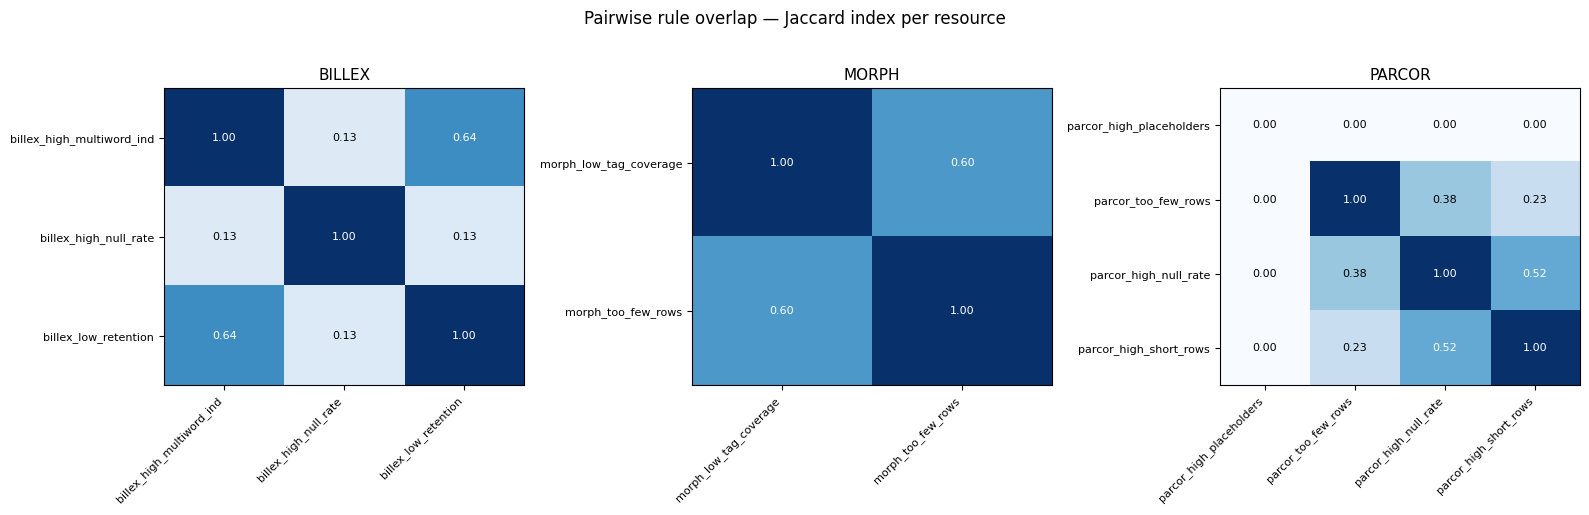

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, resource in zip(axes, ["billex", "morph", "parcor"]):
    if resource not in jaccard_matrices_by_resource:
        ax.text(0.5, 0.5, f"({resource}: <2 rules)", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(resource.upper())
        continue

    jaccard_m = jaccard_matrices_by_resource[resource]
    n = len(jaccard_m)

    im = ax.imshow(jaccard_m.values, cmap="Blues", aspect="auto", vmin=0, vmax=1)
    ax.set_xticks(range(n))
    ax.set_xticklabels(jaccard_m.columns, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(n))
    ax.set_yticklabels(jaccard_m.index, fontsize=8)

    for i in range(n):
        for j in range(n):
            v = jaccard_m.values[i, j]
            color = "white" if v > 0.5 else "black"
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", color=color, fontsize=8)

    ax.set_title(f"{resource.upper()}", fontsize=11)

plt.suptitle("Pairwise rule overlap — Jaccard index per resource",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(DST_DIR / "_rule_overlap_matrix.png", dpi=120, bbox_inches="tight")
plt.show()

## 11. Catastrophic failures (extraction-stage)

In [18]:
CATASTROPHIC_ROW_THRESHOLD = 2

catastrophic = []
for _, row in metrics_df.iterrows():
    dict_id = row["dict_id"]
    prep = int(row.get("prep_rows", 0) or 0)

    if pd.notna(row.get("billex_rows")) and row["billex_rows"] <= CATASTROPHIC_ROW_THRESHOLD and prep > 100:
        catastrophic.append({
            "dict_id": dict_id, "resource": "billex",
            "rows": int(row["billex_rows"]), "prep_rows": prep,
            "suspected_cause": "Extraction-stage failure in notebook 9 (Bilingual Lexicon).",
        })
    if pd.notna(row.get("morph_rows")) and row["morph_rows"] <= CATASTROPHIC_ROW_THRESHOLD and prep > 100:
        catastrophic.append({
            "dict_id": dict_id, "resource": "morph",
            "rows": int(row["morph_rows"]), "prep_rows": prep,
            "suspected_cause": "Morphology extraction produced nothing — extractor failed or no derivations in source.",
        })
    if (pd.notna(row.get("parcor_rows")) and row["parcor_rows"] <= CATASTROPHIC_ROW_THRESHOLD
        and row.get("parcor_has_examples_in_source", False)):
        catastrophic.append({
            "dict_id": dict_id, "resource": "parcor",
            "rows": int(row["parcor_rows"]), "prep_rows": prep,
            "suspected_cause": "Source has example sentences but Parcor is empty — extraction-stage failure in notebook 11.",
        })

cat_df = pd.DataFrame(catastrophic)
cat_df.to_csv(DST_DIR / "_catastrophic_failures.csv", index=False)
print(f"=== {len(cat_df)} catastrophic failures detected ===")
if len(cat_df) > 0:
    print(cat_df.head(10).to_string(index=False))

=== 21 catastrophic failures detected ===
dict_id resource  rows  prep_rows                                                                        suspected_cause
      3    morph     1        833 Morphology extraction produced nothing — extractor failed or no derivations in source.
     20   billex     0       2109                            Extraction-stage failure in notebook 9 (Bilingual Lexicon).
     20    morph     0       2109 Morphology extraction produced nothing — extractor failed or no derivations in source.
     22    morph     0        365 Morphology extraction produced nothing — extractor failed or no derivations in source.
     29   billex     1       1979                            Extraction-stage failure in notebook 9 (Bilingual Lexicon).
     29    morph     2       1979 Morphology extraction produced nothing — extractor failed or no derivations in source.
     31   billex     1       1371                            Extraction-stage failure in notebook 9 (Bilingual 

## 12. Visualizations

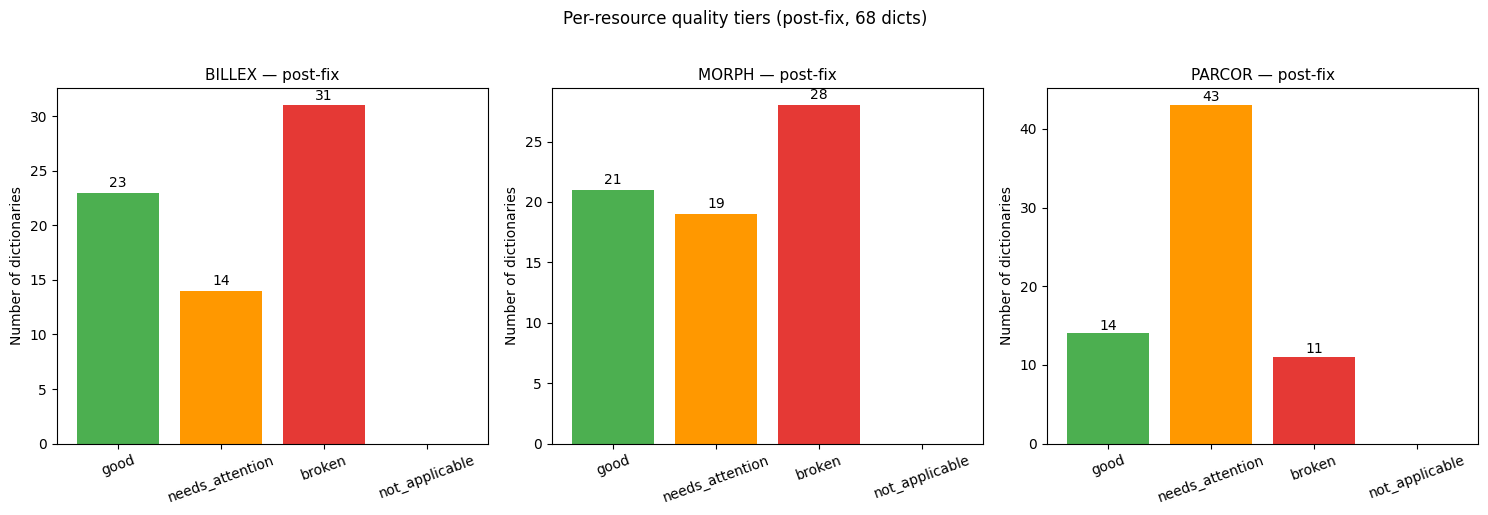

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

tier_colors = {"good": "#4caf50", "needs_attention": "#ff9800",
               "broken": "#e53935", "not_applicable": "#9e9e9e"}

for ax, resource in zip(axes, ["billex", "morph", "parcor"]):
    counts = metrics_df[f"{resource}_tier_postfix"].value_counts().reindex(tier_order, fill_value=0)
    ax.bar(counts.index, counts.values, color=[tier_colors[t] for t in counts.index])
    for i, v in enumerate(counts.values):
        if v > 0:
            ax.text(i, v + 0.5, str(v), ha="center", fontsize=10)
    ax.set_title(f"{resource.upper()} — post-fix", fontsize=11)
    ax.set_ylabel("Number of dictionaries")
    ax.tick_params(axis="x", rotation=20)

plt.suptitle(f"Per-resource quality tiers (post-fix, {len(metrics_df)} dicts)",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(DST_DIR / "_postfix_tier_breakdown.png", dpi=120, bbox_inches="tight")
plt.show()

### 12.2 Per-resource tier transitions

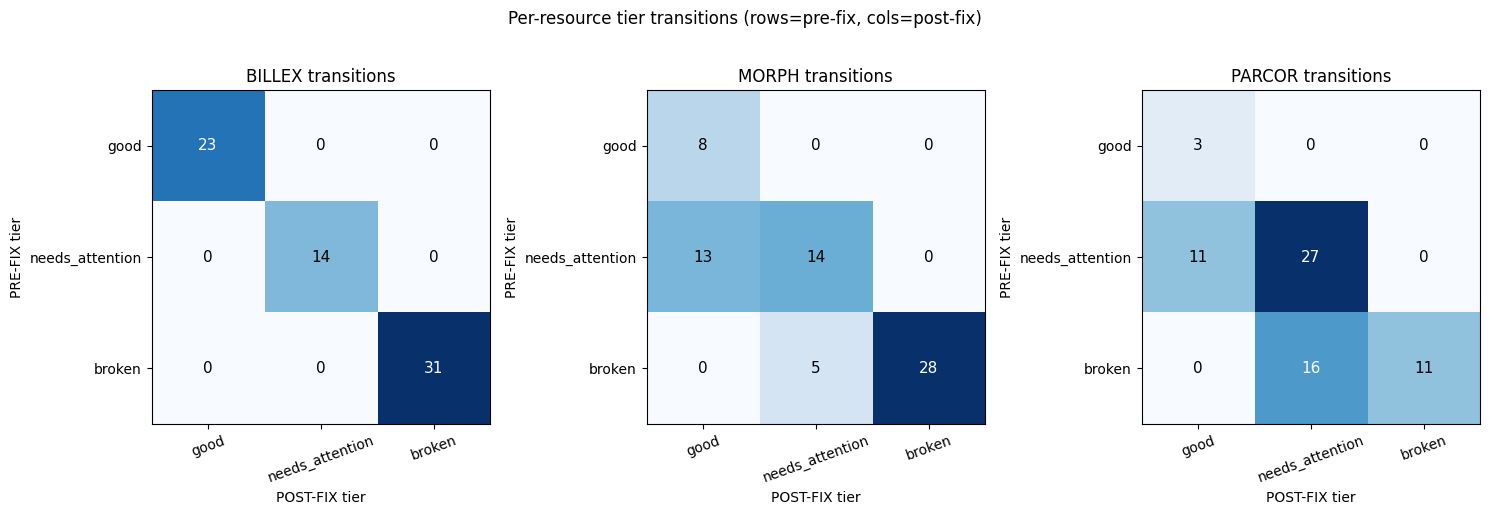

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

tier_order_no_na = ["good", "needs_attention", "broken"]

for ax, resource in zip(axes, ["billex", "morph", "parcor"]):
    trans = transitions_data[resource].drop("All", errors="ignore", axis=0).drop("All", errors="ignore", axis=1)
    trans = trans.reindex(index=tier_order_no_na, columns=tier_order_no_na, fill_value=0)

    im = ax.imshow(trans.values, cmap="Blues", aspect="auto", vmin=0)
    ax.set_xticks(range(len(tier_order_no_na)))
    ax.set_xticklabels(tier_order_no_na, rotation=20)
    ax.set_yticks(range(len(tier_order_no_na)))
    ax.set_yticklabels(tier_order_no_na)
    ax.set_xlabel("POST-FIX tier")
    ax.set_ylabel("PRE-FIX tier")
    ax.set_title(f"{resource.upper()} transitions")

    for i in range(len(tier_order_no_na)):
        for j in range(len(tier_order_no_na)):
            value = int(trans.values[i, j])
            color = "white" if value > trans.values.max() * 0.5 else "black"
            ax.text(j, i, str(value), ha="center", va="center", color=color, fontsize=11)

plt.suptitle("Per-resource tier transitions (rows=pre-fix, cols=post-fix)",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(DST_DIR / "_tier_transitions.png", dpi=120, bbox_inches="tight")
plt.show()

## 13. Aggregate summary

In [21]:
aggregate = {
    "total_dictionaries_audited":    len(metrics_df),
    "broken_proportion_threshold":   BROKEN_PROPORTION_THRESHOLD,
    "n_rules_in_use":                sum(len(rules) for rules in RESOURCE_RULES.values()),
    "rules_excluded":                ",".join(sorted(EXCLUDED_RULES)),
    # Per-resource broken counts (postfix)
    "billex_postfix_broken": int((metrics_df["billex_tier_postfix"] == "broken").sum()),
    "morph_postfix_broken":  int((metrics_df["morph_tier_postfix"] == "broken").sum()),
    "parcor_postfix_broken": int((metrics_df["parcor_tier_postfix"] == "broken").sum()),
    # Catastrophic counts
    "n_dicts_3_resources_broken": int((metrics_df["n_resources_broken_postfix"] == 3).sum()),
    "n_dicts_2_resources_broken": int((metrics_df["n_resources_broken_postfix"] == 2).sum()),
    "n_dicts_1_resource_broken":  int((metrics_df["n_resources_broken_postfix"] == 1).sum()),
    "n_dicts_0_resources_broken": int((metrics_df["n_resources_broken_postfix"] == 0).sum()),
    # Tier movement per resource (kept as diagnostic)
    "dicts_billex_tier_changed": int((metrics_df["billex_tier_prefix"] != metrics_df["billex_tier_postfix"]).sum()),
    "dicts_morph_tier_changed":  int((metrics_df["morph_tier_prefix"]  != metrics_df["morph_tier_postfix"]).sum()),
    "dicts_parcor_tier_changed": int((metrics_df["parcor_tier_prefix"] != metrics_df["parcor_tier_postfix"]).sum()),    "catastrophic_failures":  int(len(cat_df)),
    # Fix evaluation summary
    "fixes_improved":  int((shift_df["verdict"] == "improved").sum()),
    "fixes_no_change": int((shift_df["verdict"] == "no_change").sum()),
    "fixes_regressed": int((shift_df["verdict"] == "regressed").sum()),
}

agg_df = pd.DataFrame([aggregate]).T.rename(columns={0: "value"})
agg_df.to_csv(DST_DIR / "_aggregate_stats.csv")
for k, v in aggregate.items():
    print(f"  {k:<38} {v}")
print(f"\nAll outputs in: {DST_DIR.resolve()}")

  total_dictionaries_audited             68
  broken_proportion_threshold            0.6
  n_rules_in_use                         9
  rules_excluded                         billex_too_few_rows
  billex_postfix_broken                  31
  morph_postfix_broken                   28
  parcor_postfix_broken                  11
  n_dicts_3_resources_broken             5
  n_dicts_2_resources_broken             19
  n_dicts_1_resource_broken              17
  n_dicts_0_resources_broken             27
  dicts_billex_tier_changed              0
  dicts_morph_tier_changed               18
  dicts_parcor_tier_changed              27
  catastrophic_failures                  21
  fixes_improved                         3
  fixes_no_change                        0
  fixes_regressed                        0

All outputs in: C:\Users\Legion\OneDrive\Documents\UNI\TA\tugas-akhir-data-mining\TAEkstraksiKamus\csvAnalysis\sanity_v4


## 14. Reading guide

**For your thesis defense, the four most defensible artifacts:**

1. **`_postfix_distributions.png` + `_fix_distribution_shifts.csv`** —
   "Did each fix script affect its target metric?" Answered with histograms
   plus quantitative shift diagnostics (effect size, percentile deltas).

2. **`_postfix_tier_breakdown.png`** — "What's the current quality
   distribution of the corpus?" Single most concise headline.

3. **`_tier_transitions.png`** — "Did fixes move dictionaries between
   tiers?" Receipt for the methodology working.

4. **`_rule_overlap_matrix.png` + `_rule_overlap_long.csv`** — "Are
   our rules independent or redundant?" Defensible answer to "why
   include rule X if rule Y already catches it?"

**For future spellcheck integration:**

When you add spellcheck-derived rules (e.g., "high spellcheck flag rate"),
they get the same treatment: per-rule flag count, overlap with structural
rules, and Jaccard against existing rules. The framework already supports
this — just add the new rule's metric to `RESOURCE_RULES` and re-run.